<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/Session_19_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is KNN

**k - Nearest neighbors** is a simple, non-paramertric algorithm(meaning it nothing about the underlying distribution of your data).

**The intuition**: it plots all data points in a geometric space,When a new, unknown data point is introduced, the algorithm calculates the distance (usually Euclidean distance) between this new point and every single point in the training set.it picks the "k" closest points and takes a majority vote

Lazy learning: kNN does not build a formula or gerneralized mathematical model during the training phase it simply store the training dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load the dataset from UCI Repository
# 1. Imports & Data Loading

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

col_names = ['Id', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
             'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei',
             'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']

# 2. Initial Data Inspection & Cleaning
df = pd.read_csv(url, header=None, names=col_names) # Load directly with names
print(df.head())

df.columns = col_names
print(df.head())

        Id  Clump Thickness  Uniformity of Cell Size  \
0  1000025                5                        1   
1  1002945                5                        4   
2  1015425                3                        1   
3  1016277                6                        8   
4  1017023                4                        1   

   Uniformity of Cell Shape  Marginal Adhesion  Single Epithelial Cell Size  \
0                         1                  1                            2   
1                         4                  5                            7   
2                         1                  1                            2   
3                         8                  1                            3   
4                         1                  3                            2   

  Bare Nuclei  Bland Chromatin  Normal Nucleoli  Mitoses  Class  
0           1                3                1        1      2  
1          10                3                2        1

In [ ]:
df.drop(['Id'], axis=1, inplace=True)
print(df.head())

   Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
0                5                        1                         1   
1                5                        4                         4   
2                3                        1                         1   
3                6                        8                         8   
4                4                        1                         1   

   Marginal Adhesion  Single Epithelial Cell Size Bare Nuclei  \
0                  1                            2           1   
1                  5                            7          10   
2                  1                            2           2   
3                  1                            3           4   
4                  3                            2           1   

   Bland Chromatin  Normal Nucleoli  Mitoses  Class  
0                3                1        1      2  
1                3                2        1      2  
2       

In [ ]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Clump Thickness              699 non-null    int64 
 1   Uniformity of Cell Size      699 non-null    int64 
 2   Uniformity of Cell Shape     699 non-null    int64 
 3   Marginal Adhesion            699 non-null    int64 
 4   Single Epithelial Cell Size  699 non-null    int64 
 5   Bare Nuclei                  699 non-null    object
 6   Bland Chromatin              699 non-null    int64 
 7   Normal Nucleoli              699 non-null    int64 
 8   Mitoses                      699 non-null    int64 
 9   Class                        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


(699, 10)

# Advanced EDA & Data Cleaning

In this dataset,a value of 2 represents a benign tumor,and 4 represents a malignant tumor.we use value count() to make sure have a healthy distribution of both classes. If our dataset had 1000 benig examples and only 1 malignabt example ,our model would struggle to learn what malignant tumor looks like.

In [ ]:
# 3. Class Distribution Analysis
df['Class'].value_counts()
theClass = df['Class']
print(theClass)
df['Class'].shape

0      2
1      2
2      2
3      2
4      2
      ..
694    2
695    2
696    4
697    4
698    4
Name: Class, Length: 699, dtype: int64


(699,)

In [ ]:
df['Class'].value_counts()/len(df)

,count
Class,
2,0.655222
4,0.344778


# Exposing and fixing the hiding missing Values

let inspect its unique values.You will see a ? character string. this represents missing data. Become machine learing models require pure numbers,we use pd .to_numeric with errors = 'coerce' to turn those ? characters into offical NaN (Not a Number) missing values, and then verify the data type change."

In [ ]:


print('Unique values in bare_nuclei before conversion:')
print(df['Bare Nuclei'].values)
print(df['Bare Nuclei'].unique())

df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei'], errors='coerce')

print('\nUnique values in bare_nuclei after conversion:')
print(set(df['Bare Nuclei'].values))

Unique values in bare_nuclei before conversion:
['1' '10' '2' '4' '1' '10' '10' '1' '1' '1' '1' '1' '3' '3' '9' '1' '1'
 '1' '10' '1' '10' '7' '1' '?' '1' '7' '1' '1' '1' '1' '1' '1' '5' '1' '1'
 '1' '1' '1' '10' '7' '?' '3' '10' '1' '1' '1' '9' '1' '1' '8' '3' '4' '5'
 '8' '8' '5' '6' '1' '10' '2' '3' '2' '8' '2' '1' '2' '1' '10' '9' '1' '1'
 '2' '1' '10' '4' '2' '1' '1' '3' '1' '1' '1' '1' '2' '9' '4' '8' '10' '1'
 '1' '1' '1' '1' '1' '1' '1' '1' '1' '6' '10' '5' '5' '1' '3' '1' '3' '10'
 '10' '1' '9' '2' '9' '10' '8' '3' '5' '2' '10' '3' '2' '1' '2' '10' '10'
 '7' '1' '10' '1' '10' '1' '1' '1' '10' '1' '1' '2' '1' '1' '1' '?' '1'
 '1' '5' '5' '1' '?' '8' '2' '1' '10' '1' '10' '5' '3' '1' '10' '1' '1'
 '?' '10' '10' '1' '1' '3' '?' '2' '10' '1' '1' '1' '1' '1' '1' '10' '10'
 '10' '1' '1' '1' '10' '1' '1' '1' '10' '10' '1' '8' '10' '8' '1' '8' '10'
 '1' '1' '1' '1' '7' '1' '1' '1' '10' '10' '1' '1' '1' '10' '5' '1' '1'
 '1' '10' '8' '1' '10' '10' '5' '1' '1' '4' '1' '1' '10' '5' '8' '

In [ ]:
## Handling Missing Values

df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei'], errors='coerce')
print(df['Bare Nuclei'].unique())


[ 1. 10.  2.  4.  3.  9.  7. nan  5.  8.  6.]


In [ ]:
print('Data types after conversion')
print(df.dtypes['Bare Nuclei'])
print(f'\n total missing NaN values : {df['Bare Nuclei'].isna().sum()}')

Data types after conversion
float64

 total missing NaN values : 16


# Statistical Distribution & Correlation Patterns


In [ ]:
## Statistical Analysis & Feature Correlations

print('summary statistics (Rounded):')
print(round(df.describe(),2))




summary statistics (Rounded):
       Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
count           699.00                   699.00                    699.00   
mean              4.42                     3.13                      3.21   
std               2.82                     3.05                      2.97   
min               1.00                     1.00                      1.00   
25%               2.00                     1.00                      1.00   
50%               4.00                     1.00                      1.00   
75%               6.00                     5.00                      5.00   
max              10.00                    10.00                     10.00   

       Marginal Adhesion  Single Epithelial Cell Size  Bare Nuclei  \
count             699.00                       699.00       683.00   
mean                2.81                         3.22         3.54   
std                 2.86                         2.21         3.64

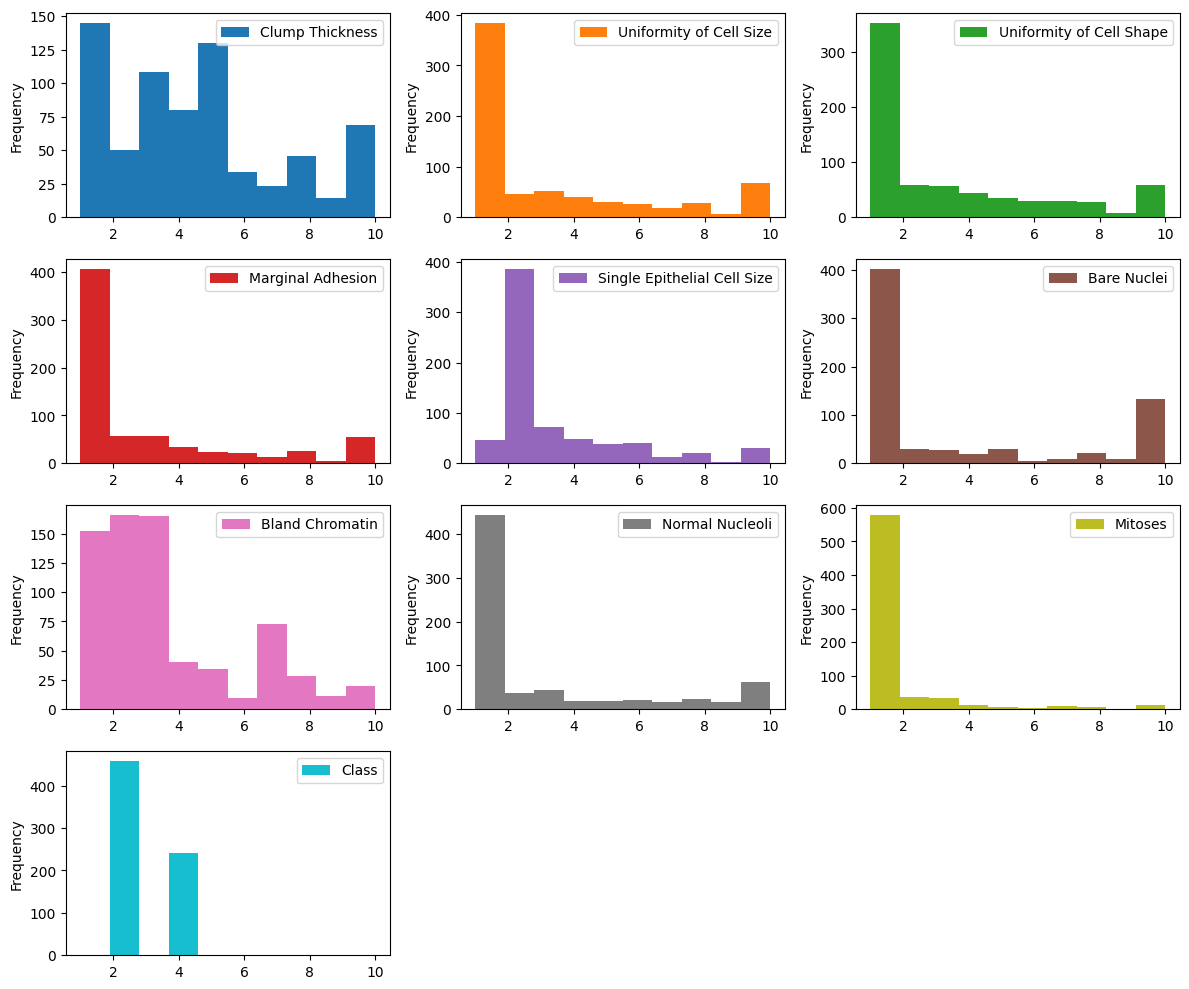

In [ ]:
# 2. Visualize distribution via histogrms
plt.rcParams['figure.figsize'] = [12,10]
df.plot(kind='hist', bins=10, subplots=True, layout=(4,3), sharex=False)
plt.tight_layout()
plt.show()


Correlation with Target Class:
Class                          1.000000
Bare Nuclei                    0.822696
Uniformity of Cell Shape       0.818934
Uniformity of Cell Size        0.817904
Bland Chromatin                0.756616
Clump Thickness                0.716001
Normal Nucleoli                0.712244
Marginal Adhesion              0.696800
Single Epithelial Cell Size    0.682785
Mitoses                        0.423170
Name: Class, dtype: float64


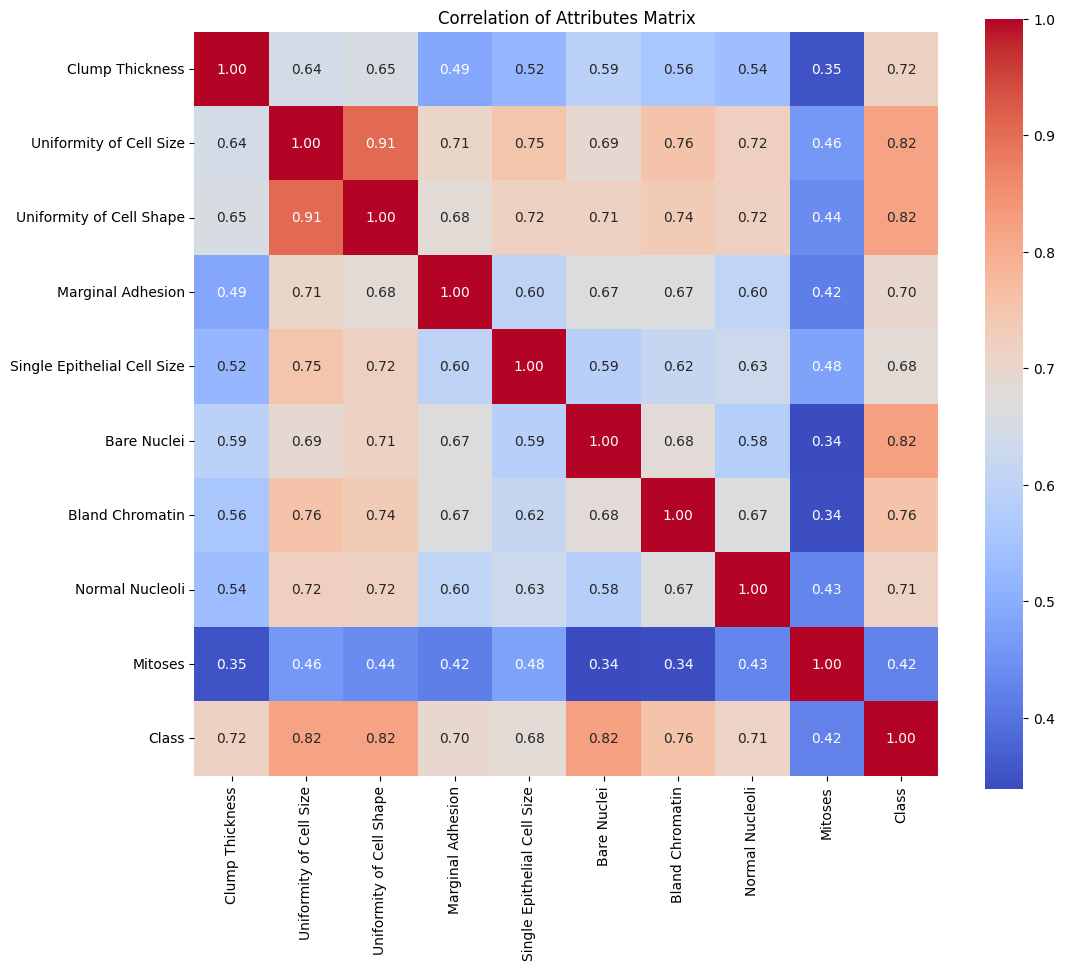

In [ ]:
# Calculate Correlation and plot heatmap

correlation = df.corr()
print('\nCorrelation with Target Class:')
print(correlation['Class'].sort_values(ascending=False))

plt.figure(figsize=(12,10))
plt.title('Correlation of Attributes Matrix')
sns.heatmap(correlation, square=True, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


# Data Preprocessing train test split and imputation


In [ ]:
## Data Splitting & Imputation

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

#X_train , x_train - contains input  y_test , y_test - contains output of the data

# Separate features (x) and target (y)
X = df.drop(['Class'], axis=1)
y = df['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Impute missing nan values using the MEDIAN from the training set
for column in X_train.columns:
    median_value = X_train[column].median()
    X_train[column]= X_train[column].fillna(median_value)
    X_test[column]=X_test[column].fillna(median_value)
print(f'X_train  Shape: {X_train.shape}')
print(f'X_test   Shape: {X_test.shape}')
print(f'y_train  Shape: {y_train.shape}')
print(f'y_test   Shape: {y_test.shape}')
print(f'missing values left in X_train:{X_train.isnull().sum().sum()}')
print(f'missing values left in X_test:{X_test.isnull().sum().sum()}')

X_train  Shape: (559, 9)
X_test   Shape: (140, 9)
y_train  Shape: (559,)
y_test   Shape: (140,)
missing values left in X_train:0
missing values left in X_test:0


# Feature Scaling

KNN relies entirely on measuring geometric distance between cooridinates, features with larger ranges will complete overwhelm features with small ranges.We use standardScaler to transform all features so they have a mean of () and a standard deviation of 1

In [ ]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler

# Save structural column names from X (the original feature DataFrame)
cols = X_train.columns

# Scaler features based on X_train fit properties
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-wrap scaled arrays back into clear pandas Dataframes
X_train = pd.DataFrame(X_train_scaled, columns=cols)
X_test = pd.DataFrame(X_test_scaled, columns=cols)

X_train.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
0,2.028383,0.299506,0.289573,1.119077,-0.546543,1.858357,-0.577774,0.041241,-0.324258
1,1.669451,2.257680,2.304569,-0.622471,3.106879,1.297589,-0.159953,0.041241,-0.324258
2,-1.202005,-0.679581,-0.717925,0.074148,-1.003220,-0.104329,-0.995595,-0.608165,-0.324258
3,-0.125209,-0.026856,-0.046260,-0.622471,-0.546543,-0.665096,-0.159953,0.041241,-0.324258
4,0.233723,-0.353219,-0.382092,-0.274161,-0.546543,-0.665096,-0.577774,-0.283462,-0.324258


# Model Training & Probability predictions

Using KNN classifier,setting hypeparameter n_neighbors = 3.

The .fit() function stores the coordinates and corresponding labels into memory.

when we call .predict(),the model returns a concrete hard prediction class (2 or 4).

If we use predict_proba(), it shows us the raw percentage confidence splits for each class

In [ ]:
## Model Training & Predictions
from sklearn.neighbors import KNeighborsClassifier

# Instantiate kNN with 3 neighbors odd number

Knn_3 = KNeighborsClassifier(n_neighbors=3)
Knn_3.fit(X_train, y_train)



KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = Knn_3.predict(X_test)
probs = Knn_3.predict_proba(X_test)
print('Class probablities for first 5 test samples:\n',probs[:5])

y_pred_proba = Knn_3.predict_proba(X_test)

# K = very less value (Underfit)

# k = very large value (Overfit)

Class probablities for first 5 test samples:
 [[1.         0.        ]
 [1.         0.        ]
 [0.33333333 0.66666667]
 [1.         0.        ]
 [0.         1.        ]]


# Model Evaluation




In [ ]:
from sklearn.metrics import accuracy_score

train_acc_3 = accuracy_score(y_train, Knn_3.predict(X_train))
test_acc_3 = accuracy_score(y_test, y_pred)

print(f'Baseline Model Training Accuracy (k=3): {train_acc_3:0.4f}')
print(f'Baseline Model Test Accuracy (k=3): {test_acc_3:0.4f}')
print(f'test-set accuracy score: {test_acc_3:0.4f}')

Baseline Model Training Accuracy (k=3): 0.9821
Baseline Model Test Accuracy (k=3): 0.9714
test-set accuracy score: 0.9714


# Confusion Matrix

TP - True Positive - YES, the patient is affected with disease

TN - True Negative - YES, the patient is not affected with disease

FP - False Positive - Patient is not affected but the result is he is affected with disease

FN - False Negative - Patient is affected with disease, But result coming as everything Normal


Error Analysis with Confusion matrix

Confusion matrix Data breakdown:
true positives (TP - Benign correct): 83
true negatives (TN - Malignant correct): 53
false positives (FP - Malignant incorrect): 2
false negatives (FN - Benign incorrect): 2


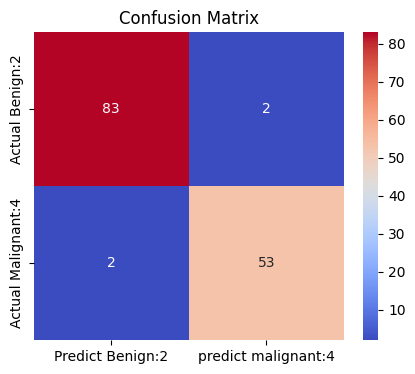

In [ ]:
## Model Evaluation & Confusion Matrix

from sklearn.metrics import confusion_matrix
cm_3 = confusion_matrix(y_test, y_pred)

cm_matrix_3 = pd.DataFrame(data=cm_3,
                           columns = ['Predict Benign:2','predict malignant:4'],
                           index=['Actual Benign:2','Actual Malignant:4'])
print('Confusion matrix Data breakdown:')
print(f'true positives (TP - Benign correct): {cm_3[0,0]}')
print(f'true negatives (TN - Malignant correct): {cm_3[1,1]}')
print(f'false positives (FP - Malignant incorrect): {cm_3[0,1]}')
print(f'false negatives (FN - Benign incorrect): {cm_3[1,0]}')

# Display clear heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm_matrix_3, annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
knn_3 = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_3.fit(X_train,y_train)
y_pred_3 = knn_3.predict(X_test)
print(f'Knn_3 prediction using Euclidean{y_pred_3}')
print(knn_3, 'Using euclidean')
print(f'Model accracy score with k=3: {accuracy_score(y_test, y_pred_3):0.4f}')



Knn_3 prediction using Euclidean[2 2 4 2 4 2 4 2 4 2 2 2 4 4 4 2 2 4 4 2 4 4 2 2 2 4 2 2 4 4 2 2 2 2 2 2 2
 4 2 2 2 2 2 2 4 4 2 4 2 4 4 2 2 4 2 2 2 2 2 2 4 2 2 4 4 4 4 2 2 4 2 2 4 4
 2 2 2 2 4 2 2 2 4 2 2 2 4 2 4 4 2 2 2 4 2 2 2 4 2 4 4 2 2 2 4 2 2 2 2 2 4
 4 4 2 2 2 2 2 4 4 4 4 2 4 2 2 4 4 4 4 4 2 2 4 4 2 2 4 2 2]
KNeighborsClassifier(metric='euclidean', n_neighbors=3) Using euclidean
Model accracy score with k=3: 0.9714


In [ ]:
knn_3 = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_3.fit(X_train,y_train)
y_pred_3 = knn_3.predict(X_test)
print(f'Knn_3 prediction using manhattan{y_pred_3}')
print(knn_3, 'Using manhattan')
print(f'Model accracy score with k=3: {accuracy_score(y_test, y_pred_3):0.4f}')



Knn_3 prediction using manhattan[2 2 4 2 4 2 4 2 4 2 2 2 4 4 4 2 2 4 4 2 4 4 2 2 2 4 2 2 4 4 2 2 2 2 2 2 2
 4 2 2 2 2 2 2 4 4 2 4 2 4 4 2 2 4 2 2 2 2 2 2 4 2 2 4 4 4 4 2 2 4 2 2 4 4
 2 2 2 2 4 2 2 2 4 2 2 2 4 2 4 4 2 2 2 4 2 2 2 4 2 4 4 2 2 2 4 2 2 2 2 2 4
 4 4 2 2 2 2 2 4 4 4 4 2 4 2 2 4 4 4 4 4 2 2 4 4 2 2 4 2 2]
KNeighborsClassifier(metric='manhattan', n_neighbors=3) Using manhattan
Model accracy score with k=3: 0.9714


In [ ]:
knn_3 = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=1)
knn_3.fit(X_train,y_train)
y_pred_3 = knn_3.predict(X_test)
print(f'Knn_3 prediction using minkowski{y_pred_3}')
print(knn_3, 'Using minkowski')
print(f'Model accracy score with k=3: {accuracy_score(y_test, y_pred_3):0.4f}')

Knn_3 prediction using minkowski[2 2 4 2 4 2 4 2 4 2 2 2 4 4 4 2 2 4 4 2 4 4 2 2 2 4 2 2 4 4 2 2 2 2 2 2 2
 4 2 2 2 2 2 2 4 4 2 4 2 4 4 2 2 4 2 2 2 2 2 2 4 2 2 4 4 4 4 2 2 4 2 2 4 4
 2 2 2 2 4 2 2 2 4 2 2 2 4 2 4 4 2 2 2 4 2 2 2 4 2 4 4 2 2 2 4 2 2 2 2 2 4
 4 4 2 2 2 2 2 4 4 4 4 2 4 2 2 4 4 4 4 4 2 2 4 4 2 2 4 2 2]
KNeighborsClassifier(n_neighbors=3, p=1) Using minkowski
Model accracy score with k=3: 0.9714
